In [1]:
import pandas as pd
df= pd.read_csv("train.csv")
df.shape




(1460, 81)

In [2]:
df.isnull().sum()[df.isnull().sum() > 0]
df['HeatingQC'].value_counts()


HeatingQC
Ex    741
TA    428
Gd    241
Fa     49
Po      1
Name: count, dtype: int64

In [3]:
df.columns.tolist()

['Id',
 'MSSubClass',
 'MSZoning',
 'LotFrontage',
 'LotArea',
 'Street',
 'Alley',
 'LotShape',
 'LandContour',
 'Utilities',
 'LotConfig',
 'LandSlope',
 'Neighborhood',
 'Condition1',
 'Condition2',
 'BldgType',
 'HouseStyle',
 'OverallQual',
 'OverallCond',
 'YearBuilt',
 'YearRemodAdd',
 'RoofStyle',
 'RoofMatl',
 'Exterior1st',
 'Exterior2nd',
 'MasVnrType',
 'MasVnrArea',
 'ExterQual',
 'ExterCond',
 'Foundation',
 'BsmtQual',
 'BsmtCond',
 'BsmtExposure',
 'BsmtFinType1',
 'BsmtFinSF1',
 'BsmtFinType2',
 'BsmtFinSF2',
 'BsmtUnfSF',
 'TotalBsmtSF',
 'Heating',
 'HeatingQC',
 'CentralAir',
 'Electrical',
 '1stFlrSF',
 '2ndFlrSF',
 'LowQualFinSF',
 'GrLivArea',
 'BsmtFullBath',
 'BsmtHalfBath',
 'FullBath',
 'HalfBath',
 'BedroomAbvGr',
 'KitchenAbvGr',
 'KitchenQual',
 'TotRmsAbvGrd',
 'Functional',
 'Fireplaces',
 'FireplaceQu',
 'GarageType',
 'GarageYrBlt',
 'GarageFinish',
 'GarageCars',
 'GarageArea',
 'GarageQual',
 'GarageCond',
 'PavedDrive',
 'WoodDeckSF',
 'OpenPorchSF'

EDA for feature engineering and dropping reduntant values

In [4]:
# DROPPED COLUMNS AND REASONS
dropped = {
    'PoolQC': 'only 3 houses have pool, not enough data',
    'RoofMatl': '99% same value, no variation',
    'GarageCond': 'redundant with GarageQual, lower variation',
    'Alley': 'only 91 houses have alley access, not enough data',
    'Utilities': '99% same value, no variation',
    'Heating': '99% same value, no variation',
    'LowQualFinSF': 'limited data availability',
    'PoolArea': 'limited data availability',
    'MiscFeature': 'lot of missing values ',
    'MiscVal': 'limited data availability',
    'LandSlope': '99% same value, no variation',
    'BsmtHalfBath': 'limited data availability',
    'BsmtFinSF2': 'limited data availability',
    'BsmtFinType2': '99% same value, no variation',
    'BsmtUnfSF': 'limited data availability',
    'KitchenAbvGr': '99% same value, no variation',
    'GarageCond': 'redundant with GarageQual, lower variation',
    'MoSold': ' it do not affect the price of the house',
    'YrSold': ' it do not affect the price of the house',
    'OpenPorchSF': 'combined with other porch features to create TotalPorchSF',
    'EnclosedPorch': 'combined with other porch features to create TotalPorchSF',
    '3SsnPorch': 'combined with other porch features to create TotalPorchSF',
    'ScreenPorch': 'combined with other porch features to create TotalPorchSF',
    'BsmtFinSF1':'already have total basement sf',
    'BsmtFinSF2': 'already have total basement sf',
    'BsmtUnfSF': 'already have total basement sf',
    'OverallCond': ' less impact on price compared to OverallQuall, corr in negative',
    
    
}


    # add every column you drop here


In [5]:
df['Street'].value_counts()


Street
Pave    1454
Grvl       6
Name: count, dtype: int64

In [6]:
# Create combined columns first
df['TotalPorchSF'] = df['OpenPorchSF'] + df['EnclosedPorch'] + df['3SsnPorch'] + df['ScreenPorch']
df.shape


(1460, 82)

In [7]:
df.shape

(1460, 82)

In [8]:
df = df.drop(columns=list(dropped.keys()), errors='ignore')
df.shape

(1460, 58)

In [9]:
print(df['OverallQual'].value_counts().sort_index())


OverallQual
1       2
2       3
3      20
4     116
5     397
6     374
7     319
8     168
9      43
10     18
Name: count, dtype: int64


In [10]:
print(df['OverallQual'].corr(df['SalePrice']))


0.7909816005838052


In [11]:
print(df['TotalBsmtSF'].corr(df['SalePrice']))

0.6135805515591954


In [12]:
df['LotArea'].value_counts()
df['LotArea'].isnull().sum()

np.int64(0)

In [13]:
corr = df.corr(numeric_only=True)['SalePrice'].sort_values(ascending=False)
print(corr.to_string())

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
GarageYrBlt     0.486362
MasVnrArea      0.477493
Fireplaces      0.466929
LotFrontage     0.351799
WoodDeckSF      0.324413
2ndFlrSF        0.319334
HalfBath        0.284108
LotArea         0.263843
BsmtFullBath    0.227122
TotalPorchSF    0.195739
BedroomAbvGr    0.168213
Id             -0.021917
MSSubClass     -0.084284


In [14]:
df['MSSubClass'].dtype

dtype('int64')

In [15]:
df.groupby('MSSubClass')['SalePrice'].mean().sort_values(ascending=False)


MSSubClass
60     239948.501672
120    200779.080460
75     192437.500000
20     185224.811567
80     169736.551724
70     166772.416667
40     156125.000000
85     147810.000000
50     143302.972222
160    138647.380952
90     133541.076923
190    129613.333333
45     108591.666667
180    102300.000000
30      95829.724638
Name: SalePrice, dtype: float64

In [16]:
df['MSSubClass'] = df['MSSubClass'].astype(str)

MISSING VALUES HANDELLING

REASONS:
1) Electrical:- using mode since it is a categorical feature and the missing proportion is negligible.
2) MasVnrType:- filled missing values with `None` where masonry veneer was absent (`MasVnrArea = 0`), while inconsistent rows with existing veneer area were filled using mode.
3) MasVnrArea:- filled missing values with `0.0` for houses without masonry veneer.
4) FireplaceQu:- filled missing values with `NoFireplace` since missing values indicated absence of fireplace.
5) LotFrontage :- filled with median frontage of same neighbourhood. Houses in same area have similar lot sizes. Smarter than global median.
6) Garage Features (GarageType, GarageYrBlt, GarageFinish, GarageQual):- missing values represented houses without garages, so categorical features were filled with `NoGarage` and `GarageYrBlt` with `0`.
7) Basement Features (BsmtQual, BsmtFinType1, BsmtCond):- missing values represented houses without basements, therefore filled with `NoBasement`.
8) BsmtExposure:- one inconsistent missing value where basement existed was filled with `No`, while remaining missing values were filled with `NoBasement`.

In [17]:
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0].sort_values(ascending=False)
print(missing_values)


Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
BsmtExposure      38
BsmtQual          37
BsmtFinType1      37
BsmtCond          37
MasVnrArea         8
Electrical         1
dtype: int64


In [18]:
df['Fence'].value_counts()


Fence
MnPrv    157
GdPrv     59
GdWo      54
MnWw      11
Name: count, dtype: int64

In [19]:
df['Electrical'].value_counts()
df['Electrical'].dtype


df["Electrical"] = df["Electrical"].fillna(df["Electrical"].mode()[0])

In [20]:
[col for col in df.columns if "Garage" in col]


['GarageType',
 'GarageYrBlt',
 'GarageFinish',
 'GarageCars',
 'GarageArea',
 'GarageQual']

In [21]:
df[df["GarageType"].isnull()][
    ["GarageType", "GarageArea", "GarageCars", "GarageQual", "GarageFinish", "GarageYrBlt"]
] 

,GarageType,GarageArea,GarageCars,GarageQual,GarageFinish,GarageYrBlt
39,NaN,0,0,NaN,NaN,NaN
48,NaN,0,0,NaN,NaN,NaN
78,NaN,0,0,NaN,NaN,NaN
88,NaN,0,0,NaN,NaN,NaN
89,NaN,0,0,NaN,NaN,NaN
...,...,...,...,...,...,...
1349,NaN,0,0,NaN,NaN,NaN
1407,NaN,0,0,NaN,NaN,NaN
1449,NaN,0,0,NaN,NaN,NaN
1450,NaN,0,0,NaN,NaN,NaN


In [22]:
# Filling garage-related missing values

garage_cols = ["GarageType", "GarageFinish", "GarageQual"]

for col in garage_cols:
    df[col] = df[col].fillna("NA")

df["GarageYrBlt"] = df["GarageYrBlt"].fillna(0)

In [23]:
df['GarageType'].value_counts()

GarageType
Attchd     870
Detchd     387
BuiltIn     88
NA          81
Basment     19
CarPort      9
2Types       6
Name: count, dtype: int64

In [24]:
df[df["BsmtExposure"].isnull()][
    ["BsmtQual", "BsmtCond", "BsmtExposure", "BsmtFinType1", "TotalBsmtSF"]
]

,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,TotalBsmtSF
17,NaN,NaN,NaN,NaN,0
39,NaN,NaN,NaN,NaN,0
90,NaN,NaN,NaN,NaN,0
102,NaN,NaN,NaN,NaN,0
156,NaN,NaN,NaN,NaN,0
182,NaN,NaN,NaN,NaN,0
259,NaN,NaN,NaN,NaN,0
342,NaN,NaN,NaN,NaN,0
362,NaN,NaN,NaN,NaN,0
371,NaN,NaN,NaN,NaN,0


In [25]:
df['BsmtExposure'].value_counts()
df['BsmtQual'].value_counts()
pd.crosstab(df["BsmtQual"], df["BsmtCond"])
df.groupby("BsmtQual")["SalePrice"].mean()
df.groupby("BsmtCond")["SalePrice"].mean()


BsmtCond
Fa    121809.533333
Gd    213599.907692
Po     64000.000000
TA    183632.620900
Name: SalePrice, dtype: float64

In [26]:
# one special case where there was basement but no exposure
df.loc[948, "BsmtExposure"] = "No"

In [27]:
# Filling basement-related missing values

bsmt_cols = ["BsmtQual", "BsmtCond", "BsmtFinType1", "BsmtExposure"]

for col in bsmt_cols:
    df[col] = df[col].fillna("NA")



In [28]:
print(df[df['FireplaceQu'].isnull()]['Fireplaces'].value_counts())

Fireplaces
0    690
Name: count, dtype: int64


In [29]:
df['FireplaceQu']= df['FireplaceQu'].fillna("NA")

In [30]:
df['Fence']= df['Fence'].fillna("NA")

In [31]:
print(df[df['MasVnrType'].isnull()]['MasVnrArea'].value_counts())

MasVnrArea
0.0      859
1.0        2
288.0      1
344.0      1
312.0      1
Name: count, dtype: int64


In [32]:
df[df["MasVnrType"].isnull()][
    ["MasVnrType", "MasVnrArea"]
]

,MasVnrType,MasVnrArea
1,NaN,0.0
3,NaN,0.0
5,NaN,0.0
8,NaN,0.0
9,NaN,0.0
...,...,...
1454,NaN,0.0
1455,NaN,0.0
1457,NaN,0.0
1458,NaN,0.0


In [33]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

In [34]:
pd.reset_option('display.max_rows')
pd.reset_option('display.max_columns')

In [35]:
df['MasVnrType'].value_counts()

MasVnrType
BrkFace    445
Stone      128
BrkCmn      15
Name: count, dtype: int64

In [36]:
mode_value = df["MasVnrType"].mode()[0]

df.loc[[624, 1300, 1334], "MasVnrType"] = mode_value

In [37]:
# Filling remaining missing masonry veneer values

df["MasVnrType"] = df["MasVnrType"].fillna("None")
df["MasVnrArea"] = df["MasVnrArea"].fillna(0.0)

In [38]:
df['LotFrontage'].value_counts()

LotFrontage
60.0     143
70.0      70
80.0      69
50.0      57
75.0      53
        ... 
138.0      1
160.0      1
152.0      1
153.0      1
46.0       1
Name: count, Length: 110, dtype: int64

In [39]:
pd.set_option('display.max_rows', None)

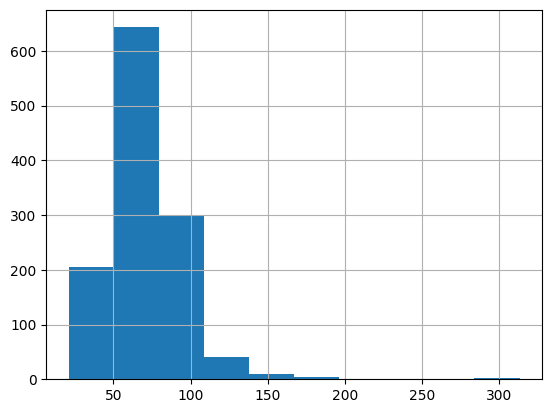

In [40]:
# lets check whether to mean or median for lot frontage
import matplotlib.pyplot as plt
df['LotFrontage'].hist()
plt.show()

In [41]:
#  above 1 means highly skewed, so we will use median to fill the missing values
print(df['LotFrontage'].skew())

2.163569142324884


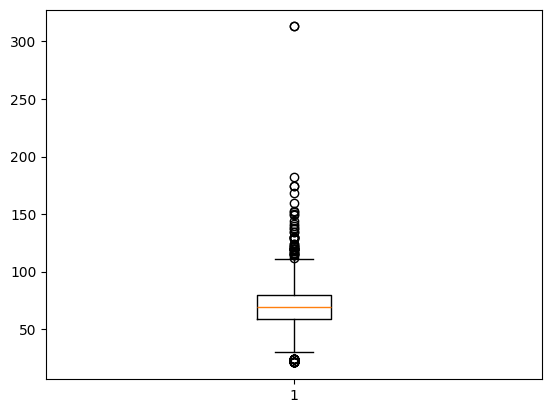

In [42]:

plt.boxplot(df["LotFrontage"].dropna())
plt.show()

In [43]:
df['LotFrontage'] = df.groupby('Neighborhood')['LotFrontage'].transform(
    lambda x: x.fillna(x.median())
)

In [44]:
df.isnull().sum().sum()

np.int64(0)

    ONE HOT ENCODING

In [45]:
list(df.select_dtypes(include="object").columns)

C:\Users\kashi\AppData\Local\Temp\ipykernel_21220\603170240.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  list(df.select_dtypes(include="object").columns)


['MSSubClass',
 'MSZoning',
 'Street',
 'LotShape',
 'LandContour',
 'LotConfig',
 'Neighborhood',
 'Condition1',
 'Condition2',
 'BldgType',
 'HouseStyle',
 'RoofStyle',
 'Exterior1st',
 'Exterior2nd',
 'MasVnrType',
 'ExterQual',
 'ExterCond',
 'Foundation',
 'BsmtQual',
 'BsmtCond',
 'BsmtExposure',
 'BsmtFinType1',
 'HeatingQC',
 'CentralAir',
 'Electrical',
 'KitchenQual',
 'Functional',
 'FireplaceQu',
 'GarageType',
 'GarageFinish',
 'GarageQual',
 'PavedDrive',
 'Fence',
 'SaleType',
 'SaleCondition']

In [46]:
df = pd.get_dummies(df)
print(df.shape)

(1460, 260)


Baseline model evaluation


In [47]:
from sklearn.model_selection import train_test_split

X=df.drop(columns=['SalePrice']) # This is DATA
y=df['SalePrice'] # This is TARGET

In [48]:
X_train, X_test, y_train, y_test= train_test_split(X, y, test_size=0.25, random_state=42)



In [49]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (1095, 259)
X_test: (365, 259)
y_train: (1095,)
y_test: (365,)


In [50]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [51]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

y_pred= model.predict(X_test)

rmse=np.sqrt(mean_squared_error(y_test, y_pred))
r2= r2_score(y_test, y_pred)


print(f"RMSE: {rmse:,.0f}")
print(f"R2 Score: {r2:.4f}")

RMSE: 31,237
R2 Score: 0.8607


In [52]:
model.score(X_train, y_train)


0.9030809885460374

In [53]:
model.score(X_test, y_test)

0.8607168551404278

In [54]:
df["SalePrice"].mean()

np.float64(180921.19589041095)

In [55]:
df["SalePrice"].median()

np.float64(163000.0)

In [56]:
df["SalePrice"].min(), df["SalePrice"].max()

(np.int64(34900), np.int64(755000))

Analysing and removing outliers from sale price

In [57]:
df["SalePrice"].describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

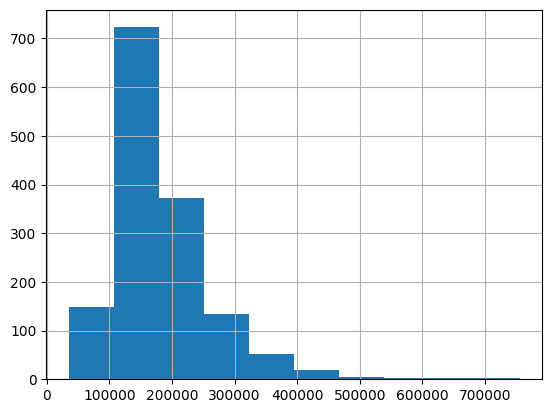

In [58]:
df["SalePrice"].hist()
plt.show()

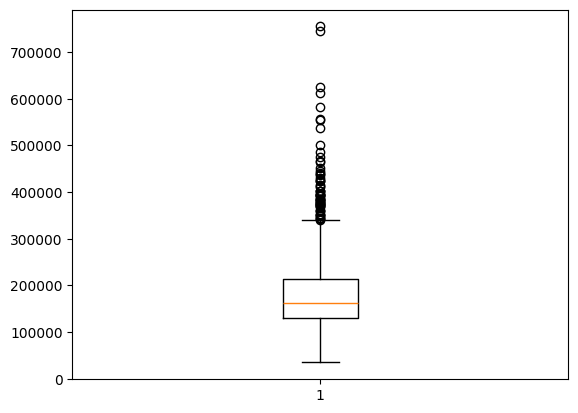

In [59]:
plt.boxplot(df["SalePrice"])
plt.show()

In [60]:
print((df['SalePrice'] > 350000).sum())

54


In [61]:
X=df.drop(columns=['SalePrice']) # This is DATA
y=df['SalePrice'] # This is TARGET

In [62]:
X_train, X_test, y_train, y_test=train_test_split(X,y, test_size=0.25, random_state=42)



In [63]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (1095, 259)
X_test: (365, 259)
y_train: (1095,)
y_test: (365,)


Evaluating performance after removing outliers from saleprice

In [64]:
model= LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [65]:
y_pred= model.predict(X_test)

rmse=np.sqrt(mean_squared_error(y_test, y_pred))
r2= r2_score(y_test, y_pred)


print(f"RMSE: {rmse:,.0f}")
print(f"R2 Score: {r2:.4f}")

RMSE: 31,237
R2 Score: 0.8607


In [66]:
df["SalePrice"].mean()

np.float64(180921.19589041095)

In [67]:
df["SalePrice"].median()

np.float64(163000.0)

In [68]:
df["SalePrice"].skew()

np.float64(1.8828757597682129)

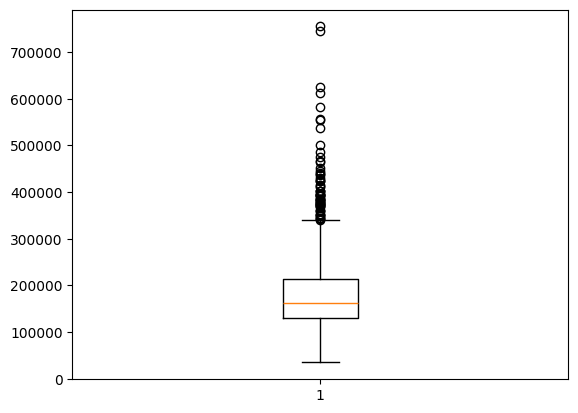

In [69]:
plt.boxplot(df["SalePrice"])
plt.show()

Scaling

In [70]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [71]:
model = LinearRegression()
model.fit(X_train_scaled, y_train)

y_pred=model.predict(X_test_scaled)

rmse=np.sqrt(mean_squared_error(y_test, y_pred))
r2= r2_score(y_test, y_pred)    

print(f"RMSE: {rmse:,.0f}")
print(f"R2 Score: {r2:.4f}")
                     
                     

RMSE: 31,008
R2 Score: 0.8627


Some more feature engineering

In [72]:
df['check'] = df['1stFlrSF'] + df['2ndFlrSF']
print((df['check'] == df['GrLivArea']).value_counts())

True     1434
False      26
Name: count, dtype: int64


In [73]:
df = df.drop(columns=['1stFlrSF', '2ndFlrSF', 'check'])
df.shape

(1460, 258)

In [74]:
df['TotalBath'] = df['FullBath'] + df['HalfBath'] + df['BsmtFullBath']
df.shape

(1460, 259)

In [75]:
df=df.drop(columns=['FullBath', 'HalfBath', 'BsmtFullBath'])


In [76]:
df.shape

(1460, 256)

In [77]:
df.columns.tolist()

['Id',
 'LotFrontage',
 'LotArea',
 'OverallQual',
 'YearBuilt',
 'YearRemodAdd',
 'MasVnrArea',
 'TotalBsmtSF',
 'GrLivArea',
 'BedroomAbvGr',
 'TotRmsAbvGrd',
 'Fireplaces',
 'GarageYrBlt',
 'GarageCars',
 'GarageArea',
 'WoodDeckSF',
 'SalePrice',
 'TotalPorchSF',
 'MSSubClass_120',
 'MSSubClass_160',
 'MSSubClass_180',
 'MSSubClass_190',
 'MSSubClass_20',
 'MSSubClass_30',
 'MSSubClass_40',
 'MSSubClass_45',
 'MSSubClass_50',
 'MSSubClass_60',
 'MSSubClass_70',
 'MSSubClass_75',
 'MSSubClass_80',
 'MSSubClass_85',
 'MSSubClass_90',
 'MSZoning_C (all)',
 'MSZoning_FV',
 'MSZoning_RH',
 'MSZoning_RL',
 'MSZoning_RM',
 'Street_Grvl',
 'Street_Pave',
 'LotShape_IR1',
 'LotShape_IR2',
 'LotShape_IR3',
 'LotShape_Reg',
 'LandContour_Bnk',
 'LandContour_HLS',
 'LandContour_Low',
 'LandContour_Lvl',
 'LotConfig_Corner',
 'LotConfig_CulDSac',
 'LotConfig_FR2',
 'LotConfig_FR3',
 'LotConfig_Inside',
 'Neighborhood_Blmngtn',
 'Neighborhood_Blueste',
 'Neighborhood_BrDale',
 'Neighborhood_BrkS

In [78]:
df=df.drop(columns=['Id'])

In [79]:
print(df[['BedroomAbvGr', 'TotRmsAbvGrd']].head(10))

   BedroomAbvGr  TotRmsAbvGrd
0             3             8
1             3             6
2             3             6
3             3             7
4             4             9
5             1             5
6             3             7
7             3             7
8             2             8
9             2             5


In [80]:
df = df.drop(columns=['BedroomAbvGr'])


In [81]:
df.shape

(1460, 254)

Analysing and removing skewness

In [82]:
skewness = df.select_dtypes(include='number').skew().sort_values(ascending=False)
print(skewness)

LotArea         12.207688
MasVnrArea       2.677616
LotFrontage      2.212959
TotalPorchSF     2.000029
SalePrice        1.882876
WoodDeckSF       1.541376
TotalBsmtSF      1.524255
GrLivArea        1.366560
TotRmsAbvGrd     0.676341
Fireplaces       0.649565
TotalBath        0.280405
OverallQual      0.216944
GarageArea       0.179981
GarageCars      -0.342549
YearRemodAdd    -0.503562
YearBuilt       -0.613461
GarageYrBlt     -3.869501
dtype: float64


<Axes: >

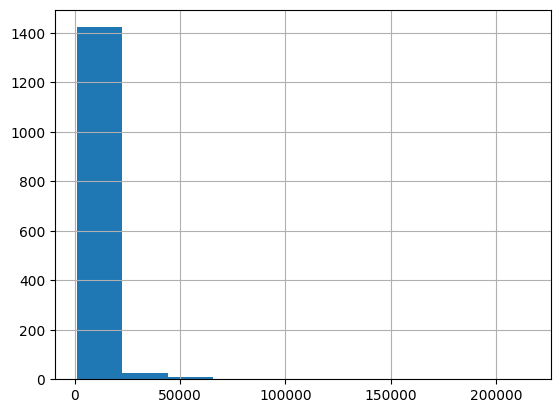

In [83]:
df['LotArea'].hist()

In [84]:
df['LotArea'] = np.log1p(df['LotArea'])


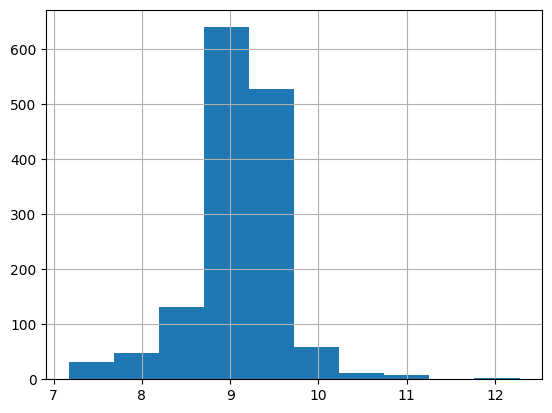

In [85]:
df['LotArea'].hist()
plt.show()


In [86]:
df['LotArea'].skew()

np.float64(-0.13740448122837784)

<Axes: >

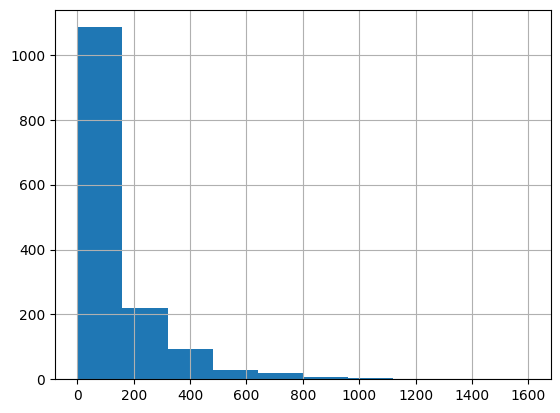

In [87]:
df['MasVnrArea'].hist()

In [88]:
df["MasVnrArea"].corr(df["SalePrice"])

np.float64(0.47261449900457386)

In [89]:
df['MasVnrArea']= np.log1p(df['MasVnrArea'])
df['MasVnrArea'].skew()

np.float64(0.5035317177020202)

<Axes: >

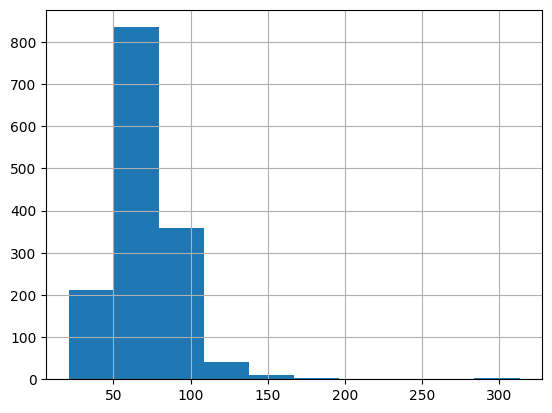

In [90]:
df['LotFrontage'].hist()

<Axes: >

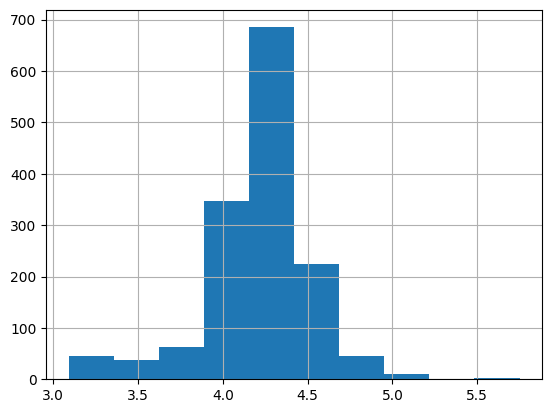

In [91]:
df['LotFrontage']= np.log1p(df['LotFrontage'])
df['LotFrontage'].hist()

<Axes: >

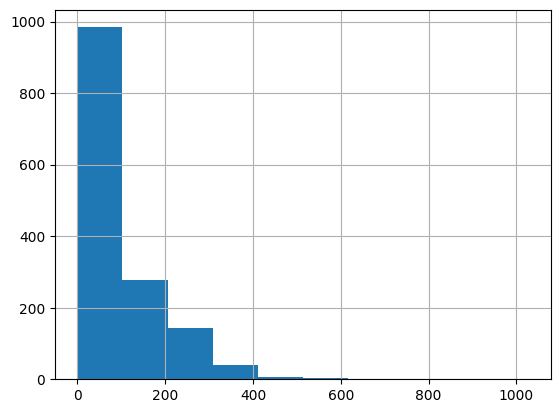

In [92]:
df['TotalPorchSF'].hist()

In [93]:
df['TotalPorchSF']= np.log1p(df['TotalPorchSF'])
df['TotalPorchSF'].skew()

np.float64(-0.5130896385598595)

In [94]:
df['TotalPorchSF'] = np.expm1(df['TotalPorchSF'])

In [95]:
df['TotalPorchSF']= np.log1p(df['TotalPorchSF'])
df['TotalPorchSF'].skew()

np.float64(-0.5130896385598595)

<Axes: >

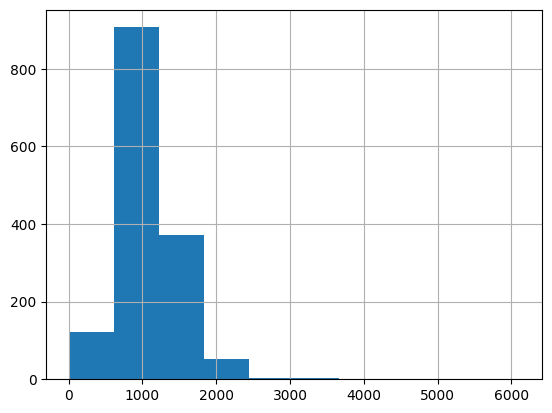

In [96]:
df['TotalBsmtSF'].hist()

In [97]:
df['TotalBsmtSF']= np.log1p(df['TotalBsmtSF'])
df['TotalBsmtSF'].skew()

np.float64(-5.1546699835179135)

<Axes: >

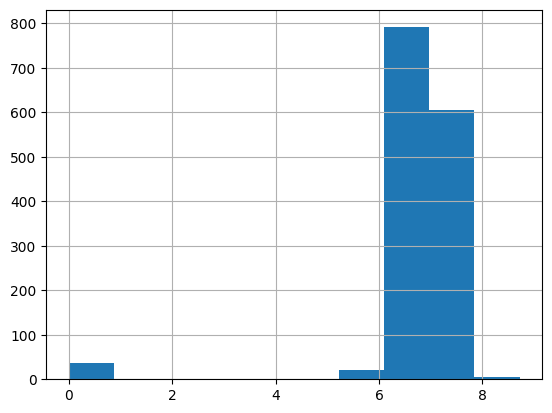

In [98]:
df['TotalBsmtSF'].hist()

In [99]:
df['TotalBsmtSF']= np.expm1(df['TotalBsmtSF'])

<Axes: >

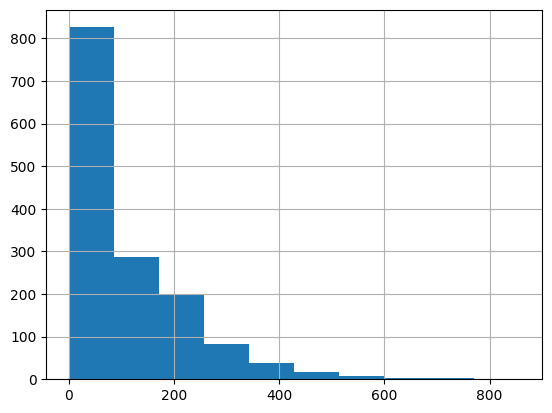

In [100]:
df['WoodDeckSF'].hist()

In [101]:
df['WoodDeckSF']= np.log1p(df['WoodDeckSF'])
df['WoodDeckSF'].skew()

np.float64(0.15353659020909782)

<Axes: >

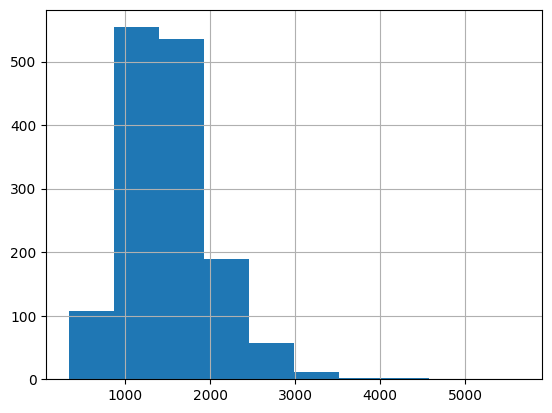

In [102]:
df['GrLivArea'].hist()

In [103]:
df['GrLivArea']= np.log1p(df['GrLivArea'])
df['GrLivArea'].skew()

np.float64(-0.006140253486287281)

In [104]:
df.shape

(1460, 254)

Evaluating performance after reducing skewness

In [105]:
X=df.drop(columns=['SalePrice']) # This is DATA
y=(df['SalePrice']) # This is TARGET

In [106]:
X_train, X_test, y_train, y_test= train_test_split(X, y, test_size=0.25, random_state=42)

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LinearRegression()
model.fit(X_train_scaled, y_train)

y_pred= model.predict(X_test_scaled)

rmse=np.sqrt(mean_squared_error(y_test, y_pred))
r2= r2_score(y_test, y_pred)

print(f"RMSE: {rmse:,.0f}")
print(f"R2 Score: {r2:.4f}")

RMSE: 32,775
R2 Score: 0.8467


Evaluation with different models

In [107]:
from sklearn.ensemble import RandomForestRegressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)

y_pred_rf = rf_model.predict(X_test_scaled)

rmse_rf=np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf= r2_score(y_test, y_pred_rf)

print(f"Random Forest RMSE: {rmse_rf:,.0f}")
print(f"Random Forest R2 Score: {r2_rf:.4f}")

Random Forest RMSE: 28,193
Random Forest R2 Score: 0.8865


In [108]:
from sklearn.tree import DecisionTreeRegressor

model_dt = DecisionTreeRegressor(random_state=42)
model_dt.fit(X_train_scaled, y_train)

y_pred_dt = model_dt.predict(X_test_scaled)
rmse_dt=np.sqrt(mean_squared_error(y_test, y_pred_dt))
r2_dt= r2_score(y_test, y_pred_dt)

print(f"Decision Tree RMSE: {rmse_dt:,.0f}")
print(f"Decision Tree R2 Score: {r2_dt:.4f}")


Decision Tree RMSE: 42,121
Decision Tree R2 Score: 0.7467


In [109]:
y_train_pred = model_dt.predict(X_train_scaled)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
print(f"Train RMSE: {train_rmse:,.0f}")
print(f"Test RMSE: 32,289")

Train RMSE: 0
Test RMSE: 32,289


In [110]:
from sklearn.tree import DecisionTreeRegressor

model_dt = DecisionTreeRegressor(max_depth=5, random_state=42)
model_dt.fit(X_train_scaled, y_train)

y_pred_dt = model_dt.predict(X_test_scaled)
rmse_dt=np.sqrt(mean_squared_error(y_test, y_pred_dt))
r2_dt= r2_score(y_test, y_pred_dt)

print(f"Decision Tree RMSE: {rmse_dt:,.0f}")
print(f"Decision Tree R2 Score: {r2_dt:.4f}")


Decision Tree RMSE: 39,231
Decision Tree R2 Score: 0.7803


In [111]:
y_train_pred = model_dt.predict(X_train_scaled)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
print(f"Train RMSE: {train_rmse:,.0f}")
print(f"Test RMSE: 29,745")

Train RMSE: 29,103
Test RMSE: 29,745


In [112]:
from sklearn.tree import DecisionTreeRegressor

model_dt = DecisionTreeRegressor(max_depth=8, random_state=42)
model_dt.fit(X_train_scaled, y_train)

y_pred_dt = model_dt.predict(X_test_scaled)
rmse_dt=np.sqrt(mean_squared_error(y_test, y_pred_dt))
r2_dt= r2_score(y_test, y_pred_dt)

print(f"Decision Tree RMSE: {rmse_dt:,.0f}")
print(f"Decision Tree R2 Score: {r2_dt:.4f}")


Decision Tree RMSE: 41,219
Decision Tree R2 Score: 0.7575


In [113]:
from sklearn.tree import DecisionTreeRegressor

model_dt = DecisionTreeRegressor(max_depth=10, random_state=42)
model_dt.fit(X_train_scaled, y_train)

y_pred_dt = model_dt.predict(X_test_scaled)
rmse_dt=np.sqrt(mean_squared_error(y_test, y_pred_dt))
r2_dt= r2_score(y_test, y_pred_dt)

print(f"Decision Tree RMSE: {rmse_dt:,.0f}")
print(f"Decision Tree R2 Score: {r2_dt:.4f}")


Decision Tree RMSE: 42,632
Decision Tree R2 Score: 0.7405


In [114]:
from sklearn.ensemble import RandomForestRegressor
rf_model = RandomForestRegressor(n_estimators=500, random_state=42)
rf_model.fit(X_train_scaled, y_train)

y_pred_rf = rf_model.predict(X_test_scaled)

rmse_rf=np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf= r2_score(y_test, y_pred_rf)

print(f"Random Forest RMSE: {rmse_rf:,.0f}")
print(f"Random Forest R2 Score: {r2_rf:.4f}")

Random Forest RMSE: 28,244
Random Forest R2 Score: 0.8861


In [115]:
from sklearn.ensemble import RandomForestRegressor
rf_model = RandomForestRegressor(n_estimators=500, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

rmse_rf=np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf= r2_score(y_test, y_pred_rf)

print(f"Random Forest RMSE: {rmse_rf:,.0f}")
print(f"Random Forest R2 Score: {r2_rf:.4f}")

Random Forest RMSE: 28,269
Random Forest R2 Score: 0.8859


In [116]:
X_train, X_test, y_train, y_test= train_test_split(X, y, test_size=0.25, random_state=42)

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LinearRegression()
model.fit(X_train_scaled, y_train)

y_pred= model.predict(X_test_scaled)

rmse=np.sqrt(mean_squared_error(y_test, y_pred))
r2= r2_score(y_test, y_pred)

print(f"RMSE: {rmse:,.0f}")
print(f"R2 Score: {r2:.4f}")

RMSE: 32,775
R2 Score: 0.8467


In [117]:
from sklearn.metrics import mean_absolute_error
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

print(f"RMSE: {rmse:,.0f}")
print(f"MAE: {mae:,.0f}")
print(f"MAPE: {mape:.1f}%")
print(f"R2: {r2:.4f}")

RMSE: 32,775
MAE: 20,964
MAPE: 12.9%
R2: 0.8467


In [118]:
from sklearn.metrics import mean_absolute_error
import numpy as np

mae_rf = mean_absolute_error(y_test, y_pred_rf)
mape_rf = np.mean(np.abs((y_test - y_pred_rf) / y_test)) * 100

print(f"RMSE_RandomForest: {rmse_rf:,.0f}")
print(f"MAE_RandomForest: {mae_rf:,.0f}")
print(f"MAPE_RandomForest: {mape_rf:.1f}%")
print(f"R2_RandomForest: {r2_rf:.4f}")

RMSE_RandomForest: 28,269
MAE_RandomForest: 17,173
MAPE_RandomForest: 10.3%
R2_RandomForest: 0.8859


In [119]:
from sklearn.metrics import mean_absolute_error
import numpy as np

mae_dt = mean_absolute_error(y_test, y_pred_dt)
mape_dt = np.mean(np.abs((y_test - y_pred_dt) / y_test)) * 100

print(f"RMSE: {rmse_dt:,.0f}")
print(f"MAE: {mae_dt:,.0f}")
print(f"MAPE: {mape_dt:.1f}%")
print(f"R2: {r2_dt:.4f}")

RMSE: 42,632
MAE: 26,409
MAPE: 15.2%
R2: 0.7405


In [120]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

xgb = XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=6, random_state=42)
xgb.fit(X_train, y_train)

preds = xgb.predict(X_test)
print("RMSE:", np.sqrt(mean_squared_error(y_test, preds)))
print("R2:", r2_score(y_test, preds))
print("MAE:", mean_absolute_error(y_test, preds))
print("MAPE:", np.mean(np.abs((y_test - preds) / y_test))*100, "%")

RMSE: 25781.952137105523
R2: 0.9051135182380676
MAE: 16676.8125
MAPE: 10.057731582817475 %


In [121]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np


xgb = XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=6, random_state=42)
xgb.fit(X_train_scaled, y_train)

preds = xgb.predict(X_test_scaled)
print("RMSE:", np.sqrt(mean_squared_error(y_test, preds)))
print("R2:", r2_score(y_test, preds))
print("MAE:", mean_absolute_error(y_test, preds))
print("MAPE:", np.mean(np.abs((y_test - preds) / y_test))*100, "%")

RMSE: 25781.952137105523
R2: 0.9051135182380676
MAE: 16676.8125
MAPE: 10.057731582817475 %


Removing skewness from saleprice

In [122]:
X=df.drop(columns=['SalePrice']) # This is DATA
y=np.log1p(df['SalePrice']) # This is TARGET

In [123]:

X_train, X_test, y_train, y_test= train_test_split(X, y, test_size=0.25, random_state=42)

from sklearn.preprocessing import StandardScaler 

scaler = StandardScaler() 

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test) 

model = LinearRegression() 
model.fit(X_train_scaled, y_train)

y_pred= model.predict(X_test_scaled)

pred_actual= np.expm1(y_pred) 
test_actual= np.expm1(y_test) 

rmse=np.sqrt(mean_squared_error(test_actual, pred_actual)) 
r2= r2_score(test_actual, pred_actual) 
print(f"RMSE: {rmse:,.0f}")
print(f"R2 Score: {r2:.4f}")
print("MAE:", mean_absolute_error(test_actual, pred_actual))
print("MAPE:", np.mean(np.abs((test_actual - pred_actual) / test_actual))*100, "%")

RMSE: 27,017
R2 Score: 0.8958
MAE: 16516.248792274637
MAPE: 9.553336953184377 %


In [124]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
from  sklearn.model_selection import train_test_split

X_train_xg, X_test_xg, y_train_xg, y_test_xg= train_test_split(X, y, test_size=0.25, random_state=42)

xgb = XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=6, random_state=42)
xgb.fit(X_train_xg, y_train_xg)

pred_xg= xgb.predict(X_test_xg)

pred_xq_actual= np.expm1(pred_xg)
y_test_xg_actual= np.expm1(y_test_xg)


print("RMSE:", np.sqrt(mean_squared_error(y_test_xg_actual, pred_xq_actual)))
print("R2:", r2_score(y_test_xg_actual, pred_xq_actual))
print("MAE:", mean_absolute_error(y_test_xg_actual, pred_xq_actual))
print("MAPE:", np.mean(np.abs((y_test_xg_actual - pred_xq_actual) / y_test_xg_actual))*100, "%")

RMSE: 25729.33473869333
R2: 0.905500433863847
MAE: 16145.659171660964
MAPE: 9.855865489824001 %


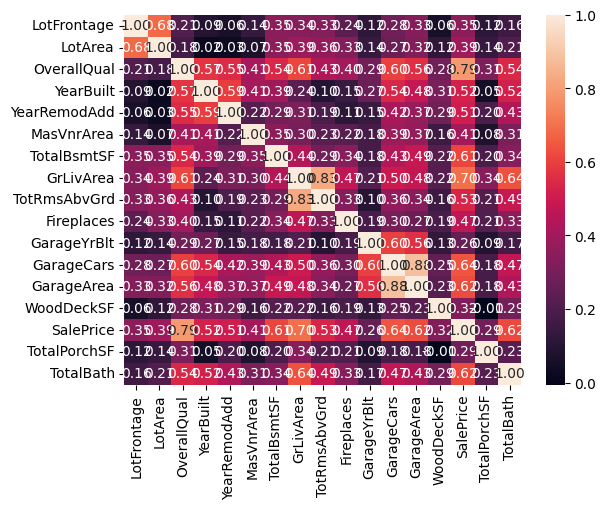

In [125]:
import seaborn as sns
import matplotlib.pyplot as plt

numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
corr_matrix = df[numerical_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f')
plt.show()

In [126]:
# Get all correlation pairs sorted by strength
corr_matrix = df[numerical_cols].corr().abs()

# Get upper triangle only (avoid duplicates)
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

# Convert to sorted list
corr_pairs = upper.stack().reset_index()
corr_pairs.columns = ['Feature 1', 'Feature 2', 'Correlation']
corr_pairs = corr_pairs.sort_values('Correlation', ascending=False)

print(corr_pairs[corr_pairs['Correlation'] > 0.5])

        Feature 1     Feature 2  Correlation
199    GarageCars    GarageArea     0.882475
127     GrLivArea  TotRmsAbvGrd     0.825521
48    OverallQual     SalePrice     0.790982
133     GrLivArea     SalePrice     0.695147
1     LotFrontage       LotArea     0.683399
201    GarageCars     SalePrice     0.640409
135     GrLivArea     TotalBath     0.637392
218    GarageArea     SalePrice     0.623431
254     SalePrice     TotalBath     0.618474
41    OverallQual     GrLivArea     0.614207
116   TotalBsmtSF     SalePrice     0.613581
45    OverallQual    GarageCars     0.600671
181   GarageYrBlt    GarageCars     0.598005
55      YearBuilt  YearRemodAdd     0.592855
37    OverallQual     YearBuilt     0.572323
46    OverallQual    GarageArea     0.562022
182   GarageYrBlt    GarageArea     0.560783
38    OverallQual  YearRemodAdd     0.550684
50    OverallQual     TotalBath     0.541267
62      YearBuilt    GarageCars     0.537850
40    OverallQual   TotalBsmtSF     0.537808
150  TotRm

In [128]:
# Check correlation of both features with SalePrice
print(df[['GarageCars', 'GarageArea', 'SalePrice']].corr()['SalePrice'])
print(df[['GrLivArea', 'TotRmsAbvGrd', 'SalePrice']].corr()['SalePrice'])

GarageCars    0.640409
GarageArea    0.623431
SalePrice     1.000000
Name: SalePrice, dtype: float64
GrLivArea       0.695147
TotRmsAbvGrd    0.533723
SalePrice       1.000000
Name: SalePrice, dtype: float64


In [129]:
df.drop(columns=['GarageArea', 'TotRmsAbvGrd'], inplace=True)